# **Eeveelutionarists**


### **Team Members**
    Azucena, Raphael Matthew 
    Mana-ay, Shawn Michael
    Mercado, Raphel Angelo
    Paguyanan, Aaron

# **Description of the dataset and the task**
This project predicts student stress levels encoded in **3 distinct binned categories** based on information about various aspects of student life including relationships, finances, student habits, and substance use.

### Problem Statement (Classification)
Predict student stress levels categorized into three distinct classes:
- **Low Stress**: Score range 1-3
- **Average Stress**: Score range 4-6  
- **High Stress**: Score range 7-10

### **Import Libraries**
Import all necessary Python libraries for data processing, machine learning, and visualization.

In [46]:
# Import standard libraries
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


### **Configure Project Paths**
Set up the project directory structure and add paths to Python's module search path for importing backend modules.

In [47]:
project_root = Path.cwd()
if not (project_root / "backend").exists() and project_root.name == "notebooks":
    project_root = project_root.parent

backend_root = project_root / "backend"
for p in (project_root, backend_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("✓ Paths configured")

✓ Paths configured


### **Import Project Modules**
Import custom modules from the backend package including data pipeline, ML utilities, and model classes.

In [48]:
import importlib

from backend import config
import backend.src.models.logistic_regression_model as _lr_mod
import backend.src.models.neural_network_model as _nn_mod
import backend.src.models.decision_tree_model as _dt_mod
import backend.src.models as _models_pkg

for _mod in (_lr_mod, _nn_mod, _dt_mod, _models_pkg):
    importlib.reload(_mod)

from backend.src.architecture.data_pipeline import DataLoader, DataCleaner, FeatureEngineer
from backend.src.architecture.ml_utils import Converters, Pipeliner, ProfileGenerator
from backend.src.architecture.ml_tasks import EDA, Evaluator, Predictor
from backend.src.architecture.visualizer import Visualizer
from backend.src.models import LogisticRegressionModel, NeuralNetworkModel, DecisionTreeModel

print("✓ Modules imported successfully")


✓ Modules imported successfully


### **Initialize Pipeline Components**
Create instances of data processing components: loader, cleaner, feature engineer, converters, visualizer, evaluator, pipeliner, predictor, and profile generator.

In [49]:
loader = DataLoader()
cleaner = DataCleaner()
engineer = FeatureEngineer()
converters = Converters()
visualizer = Visualizer()
eda = EDA(visualizer)
evaluator = Evaluator()
pipeliner = Pipeliner(config.ALL_NUMERIC, config.ALL_CATS)
predictor = Predictor()
profile_generator = ProfileGenerator(
    config.NUMERIC_COLS,
    config.CATEGORICAL_COLS,
    config.ALL_NUMERIC,
    config.ALL_CATS,
)

print("✓ Pipeline components initialized")

✓ Pipeline components initialized


### **Initialize Models**
Create instances of three classification models: Logistic Regression, Neural Network, and Decision Tree.
1. **Logistic Regression**: Baseline linear model for multi-class classification
2. **Neural Network**: Deep learning approach with multiple hidden layers
3. **Decision Tree**: Tree-based model with hyperparameter tuning


In [50]:
from backend.src.models import DecisionTreeModel

models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    DecisionTreeModel(),
]

print("✓ Models initialized")
print(f"  → {len(models)} models ready: {[m.get_name() for m in models]}")


✓ Models initialized
  → 3 models ready: ['Multinomial Logistic Regression', 'Neural Network', 'Decision Tree']


### **Data Ingestion & Initial Processing**
Loading the raw survey data from CSV file containing student responses. The dataset includes:
- **Numeric features**: age, hours_work, social_media_use, rent, friends_count, etc.
- **Categorical features**: gender, relationship_status, drug_use_ans, student_type, etc.
- **Target variable**: stress (continuous score)

Only students who provided consent for data use are included in the analysis. 

In [51]:
raw = loader.load()
raw = loader.filter_consent(raw)

cols_needed = config.NUMERIC_COLS + config.CATEGORICAL_COLS + [config.TARGET]
df = raw[cols_needed].copy()

print(f"Rows after consent: {len(raw)}")
print(f"Columns used: {len(cols_needed)}")
df.head(3)

Rows after consent: 2955
Columns used: 23


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,hours_studying,gender,relationship_status,drug_use_ans,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,40.0,4.0,400.0,2.0,150.0,NaN,6.0,NaN,4.0,...,5.0,Female,In a relationship,Yes,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0
2,19.0,40.0,200.0,200.8,0.0,-800.0,NaN,4.3,NaN,8.3,...,25.0,Female,Its complicated,Prefer not to say,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0


# **Data Cleaning**
The data cleaning process handles missing values, outliers, and data quality issues:
1. **Missing Value Detection**: Identify columns with null/NaN values
2. **Numeric Imputation**: Fill missing numeric values with median or mean
3. **Categorical Imputation**: Fill missing categorical values with mode or "Unknown"
4. **Outlier Detection**: Identify extreme values using IQR method
5. **Data Type Validation**: Ensure columns have correct data types
6. **Duplicate Removal**: Remove any duplicate survey responses

In [52]:
# CLEANING: Clip outliers to 25th–75th percentile, remove rows with missing data, and ensure correct types
df = cleaner.clean(df, config.NUMERIC_COLS,
                   config.CATEGORICAL_COLS, config.TARGET)
print(f"✓ Data cleaned: {len(df)} rows remain")


✓ Data cleaned: 2842 rows remain


# **Data Preprocessing**
Feature engineering creates derived features to capture complex relationships about student life, including financial, academic, and social factors.
1. **financial_pressure**: Calculated from rent and income indicators - captures economic stress
2. **work_study_ratio**: Balance between work hours and study hours - identifies time management challenges
3. **social_engagement**: Combination of friends_count and social_media_use - measures social connectivity
4. **stress_category**: Multi-class target derived from continuous stress scores (1-10 scale)
   - **Low**: stress scores 1-3 (minimal stress)
   - **Average**: stress scores 4-6 (moderate stress)
   - **High**: stress scores 7-10 (significant stress)

Categorical variables (gender, relationship_status, drug_use_ans, student_type, lecture_mode, study_type, learner_style) are label-encoded for correlation analysis and model training.

In [53]:
# ENGINEERING and ENCODING: Create derived features, label encode categoricals, and ensure target is correct type
df = engineer.engineer(df, config.DERIVED_COLS,
                       config.TARGET, converters, config.TARGET_CATEGORY)
print(df[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER))

stress_category
Low         773
Average    1195
High        874
Name: count, dtype: int64


### **Exploratory Data Analysis (EDA)**
Generate comprehensive EDA visualizations including distributions, correlations, and stress category analysis.

In [54]:
# Label encoded copy only for EDA/correlation
df_eda, _ = converters.label_encode(df, config.CATEGORICAL_COLS)

1. **Univariate Analysis**:
   - Distribution plots for numeric features
   - Frequency counts for categorical features
   - Summary statistics (mean, median, std, quartiles)

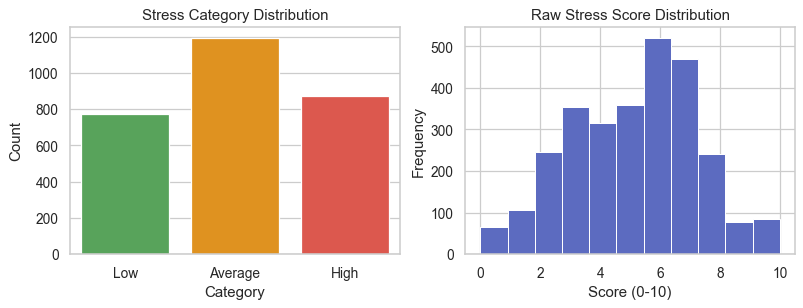

In [55]:
eda.plot_distributions(df, config.TARGET, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

2. **Bivariate Analysis**:
   - Correlation heatmap between features
   - Feature-target relationships
   - Identify multicollinearity issues

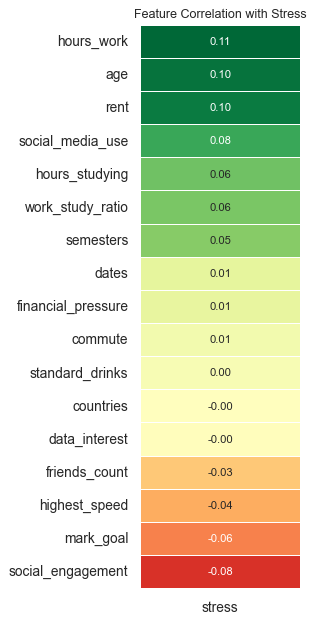

In [56]:
eda.plot_correlation_heatmap(df_eda, config.ALL_NUMERIC, config.TARGET)

3. **Target Variable Analysis**:
   - Class distribution (Low, Average, High stress)
   - Check for class imbalance
   - Visualize stress categories

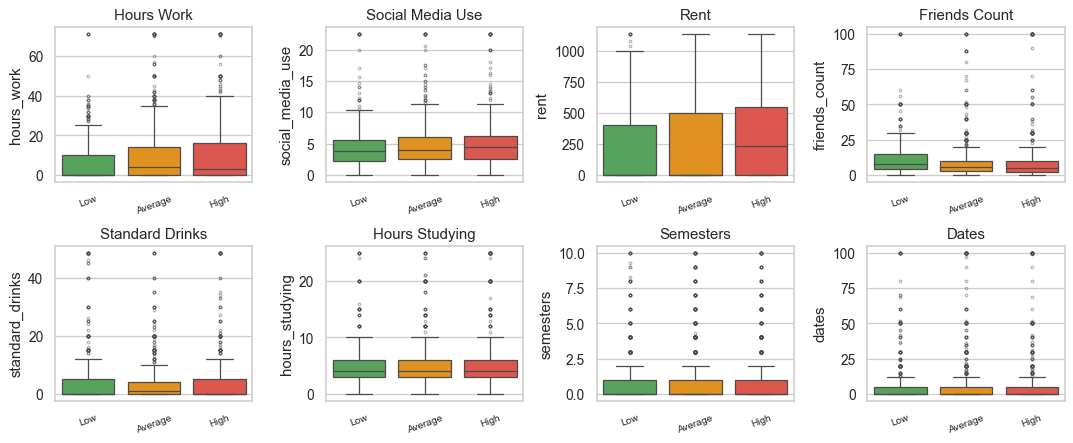

In [57]:
eda.boxplot_key_features(df, config.TARGET_CATEGORY, config.CATEGORY_ORDER)

# **Data Splitting**
- **Training Set (75%)**: Used for model learning and parameter estimation
- **Validation Set (10%)**: Used for hyperparameter tuning and model selection
- **Test Set (15%)**: Hold-out set for final unbiased performance evaluation

In [58]:
train_ratio, val_ratio, test_ratio = 0.75, 0.10, 0.15
train_path      = config.DATA_DIR / "train.csv"
validation_path = config.DATA_DIR / "validation.csv"
test_path       = config.DATA_DIR / "test.csv"
required_cols   = config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET_CATEGORY]

if all(p.exists() for p in [train_path, validation_path, test_path]):
    train_df      = pd.read_csv(train_path)[required_cols]
    validation_df = pd.read_csv(validation_path)[required_cols]
    test_df       = pd.read_csv(test_path)[required_cols]
    print("✓ Loaded existing splits")
else:
    X_raw, y_cat = df[config.ALL_NUMERIC + config.ALL_CATS], df[config.TARGET_CATEGORY]
    
    # First split: separate train (75%) from the remaining 25%
    X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y_cat, test_size=1 - train_ratio, random_state=config.SEED, stratify=y_cat)
    # Second split: divide the 25% into val (15%) and test (10%)
    X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=test_ratio / (val_ratio + test_ratio), random_state=config.SEED, stratify=y_temp)

    config.DATA_DIR.mkdir(parents=True, exist_ok=True)
    splits = {"train_df": (X_train, y_train, train_path), "validation_df": (X_val, y_val, validation_path), "test_df": (X_test, y_test, test_path)}
    for name, (X, y, path) in splits.items():
        out = X.assign(**{config.TARGET_CATEGORY: y.values})
        out.to_csv(path, index=False)
        globals()[name] = out
    print("✓ Created new splits")

for label, split in [("Train", train_df), ("Val", validation_df), ("Test", test_df)]:
    dist = split[config.TARGET_CATEGORY].value_counts().reindex(config.CATEGORY_ORDER).to_dict()
    print(f"  {label:5s}: {len(split):4d} rows | {dist}")

✓ Loaded existing splits
  Train: 2131 rows | {'Low': 580, 'Average': 896, 'High': 655}
  Val  :  284 rows | {'Low': 77, 'Average': 119, 'High': 88}
  Test :  427 rows | {'Low': 116, 'Average': 180, 'High': 131}


### **Pipeline Transformers**
Apply preprocessing pipeline (StandardScaler for numeric features, OneHotEncoder for categorical features) to transform data for model training.

In [59]:
X_train_t = pipeliner.fit_transform(train_df[config.ALL_NUMERIC + config.ALL_CATS])
X_val_t   = pipeliner.transform(validation_df[config.ALL_NUMERIC + config.ALL_CATS])
X_test_t  = pipeliner.transform(test_df[config.ALL_NUMERIC + config.ALL_CATS])
X_train = train_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_train = train_df[config.TARGET_CATEGORY]

X_val = validation_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_val = validation_df[config.TARGET_CATEGORY]

X_test = test_df[config.ALL_NUMERIC + config.ALL_CATS]
ycat_test = test_df[config.TARGET_CATEGORY]
    

# **Models**


## Multinomial Logistic Regression

### Model Appropriateness
The data asks for the classification of stress levels, specifically: low, medium, and high. A Multinomial Logistic Regression using `SGDClassifier` to classify the three classes is appropriate.

### Correctness of Model Training
The data was split into a **75% / 15% / 10%** ratio between training, validation, and testing data.

Hyperparameter tuning was performed on the following:
- Initial learning rate (`eta0`)
- Penalty (`penalty`)
- Learning rate style (`learning_rate`)

Some SGD parameters were kept constant to maintain model purpose (loss as `log_loss`) and reproducibility (`random_state=42`), with `max_iter=200` based on the loss graph.

**Best hyperparameters found:**

| Parameter | Value |
|---|---|
| `eta0` | 0.01 |
| `learning_rate` | adaptive |
| `loss` | log_loss |
| `max_iter` | 200 |
| `penalty` | l1 |
| `random_state` | 42 |

This configuration yielded a **+4% accuracy improvement** over the untuned model.

### Check for Overfitting or Underfitting
Accuracy was compared between the training and validation sets. The small difference between the two indicates the model was fit properly. The loss curve also converged, further confirming proper fitting despite low classification performance metrics.

### Error Analysis
- **Precision:** Low across all classes — the model fails to accurately predict true positives per class.
- **Recall:** Good for the *average* class, but low for others.
- **Root cause:** The confusion matrix reveals a strong bias toward classifying students as having an *average* stress level.



## Neural Network

### Model Appropriateness
The data asks for the classification of stress levels, specifically: low, average, and high. A Neural Network using a custom PyTorch-based `MLPClassifier` with multi-layer support is appropriate. Neural Networks are capable of learning complex, non-linear relationships between features and target classes, making them well-suited for a dataset where no single feature strongly predicts stress level on its own and decision boundaries between classes are not linearly separable.

### Correctness of Model Training
The data was split into a **75% / 15% / 10%** ratio between training, validation, and testing data.

Tuned hyperparameters:
- Hidden layer sizes (`hidden_layers`)
- Activation function (`activation`)
- Initial learning rate (`learning_rate`)
- Maximum training iterations (`max_iterations`)

Constant parameters: Adam optimizer, `CrossEntropyLoss` for multi-class classification, `random_state=42`.

**Best hyperparameters found:**

| Parameter | Value |
|---|---|
| `hidden_layers` | (128, 64, 32) |
| `activation` | ReLU |
| `learning_rate` | 0.001 |
| `max_iterations` | 500 |

**Performance comparison:**

| Configuration | Validation F1 | Test F1 |
|---|---|---|
| Refined Basic Model | 27.80% | — |
| Refined Best Model | 41.32% | 36.14% |

### Check for Overfitting or Underfitting
Accuracy was compared between the training and validation sets. A final loss of **0.9646** suggests the model may be overfitting.

### Error Analysis
The Neural Network achieves a test F1 of **36.14%** in the Refined Best configuration. Similar to other models, the network shows a strong bias toward classifying students into the *average* stress level class, resulting in low recall for the *low* and *high* classes.


## Decision Tree

### Model Appropriateness
The data asks for the classification of stress levels, specifically: low, average, and high. A Decision Tree Classifier is appropriate for classifying these three classes because it:
- Natively supports multi-class classification without requiring any decomposition strategy
- Naturally handles a mix of numeric and categorical features after preprocessing
- Produces interpretable split rules, making it easy to explain which features most strongly influenced a given student's stress classification (Quinlan, 1986)

### Check for Overfitting or Underfitting

Accuracy was compared between the training and validation sets to check for overfitting or underfitting.

#### Accuracy Summary

| | Train Accuracy | Validation Accuracy | Test Accuracy | Gap |
|---|---|---|---|---|
| Baseline (Unconstrained) | 50.07% | 39.08% | 40.75% | 10.99% |
| Tuned (RandomSearchCV) | 51.62% | 44.37% | 44.50% | 7.25% |

1. The unconstrained baseline tree achieves 50.07% training accuracy but only 39.08% validation accuracy — a **10.99% gap** that indicates overfitting, confirming the tree was memorizing the training set rather than learning generalized patterns.
2. After RandomSearchCV hypertuning, the final model achieves a training accuracy of **51.62%** and a validation accuracy of **44.37%**.
3. The reduced gap confirms the model is no longer severely overfitting. Training and validation accuracies are now close to each other, indicating the model generalizes appropriately to unseen data. High-gap configurations were rejected programmatically, and the training loop proceeds to the test set only once the gap falls within tolerance.
4. **Learning Curve** — the depth sweep table serves as the learning curve for this model. Unlike Neural Networks, Decision Trees do not iterate over epochs; instead, the learning curve is expressed as model complexity (depth) versus train/validation accuracy. The curve shows training accuracy increasing with depth while validation accuracy plateaus, with the optimal generalization point at approximately `max_depth = 3` to `4`.


### **Basic Training and Evaluation**

Trained: Multinomial Logistic Regression
Train acc: 0.4350  Val acc: 0.3838

── Multinomial Logistic Regression — Basic Metrics ──

  Multinomial Logistic Regression  |  Accuracy: 41.9%
              precision    recall  f1-score   support

         Low       0.39      0.14      0.20       116
     Average       0.43      0.82      0.56       180
        High       0.39      0.12      0.19       131

    accuracy                           0.42       427
   macro avg       0.40      0.36      0.32       427
weighted avg       0.41      0.42      0.35       427



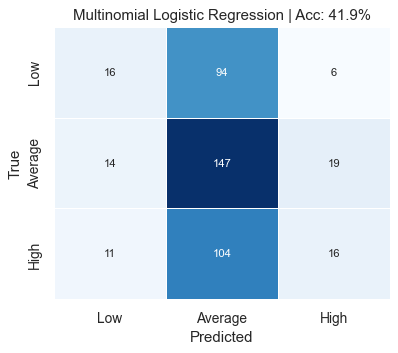

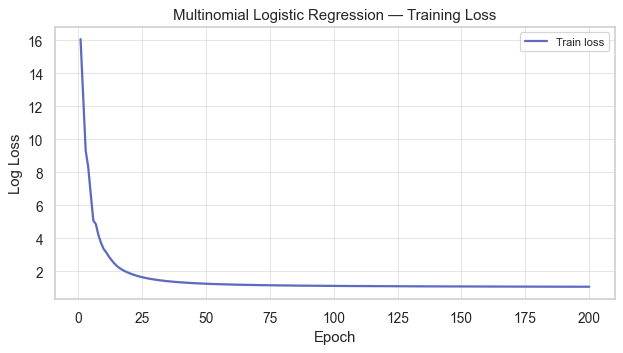


Training Neural Network (basic) ...
  Epoch 50/500  loss=1.0704  val_loss=1.0664
  Epoch 100/500  loss=1.0418  val_loss=1.0433
  Epoch 150/500  loss=1.0222  val_loss=1.0332
Early stopping at epoch 170
  Restored best model from epoch with val_loss=1.0315
  Train acc: 0.5012  Val acc: 0.4507

── Neural Network — Basic Metrics ──

  Neural Network  |  Accuracy: 38.9%
              precision    recall  f1-score   support

         Low       0.33      0.19      0.24       116
     Average       0.41      0.63      0.49       180
        High       0.37      0.24      0.29       131

    accuracy                           0.39       427
   macro avg       0.37      0.35      0.34       427
weighted avg       0.38      0.39      0.36       427



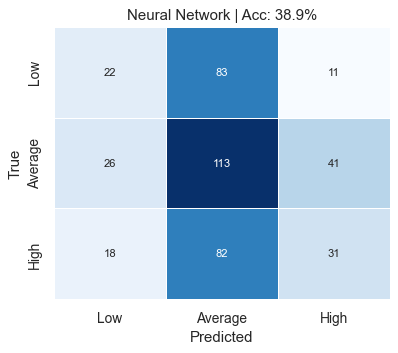

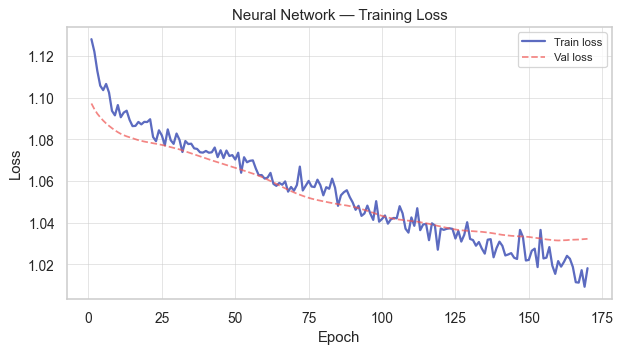

Trained (basic): Decision Tree
Train acc: 0.5007  Val acc: 0.3908

── Decision Tree — Basic Metrics ──

  Decision Tree  |  Accuracy: 40.7%
              precision    recall  f1-score   support

         Low       0.28      0.12      0.17       116
     Average       0.44      0.74      0.55       180
        High       0.38      0.21      0.27       131

    accuracy                           0.41       427
   macro avg       0.36      0.36      0.33       427
weighted avg       0.37      0.41      0.36       427



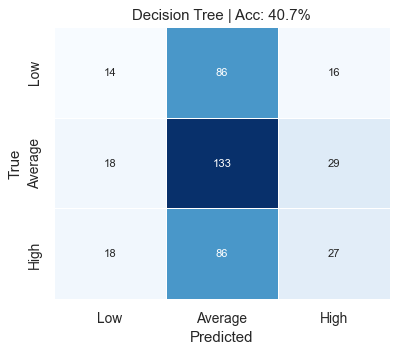

[Decision Tree] No loss curve available — Decision Trees are trained in a single pass with no iterative loss.


In [60]:
basic_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    DecisionTreeModel(),
]

basic_reports = {}
for model in basic_models:
    model.train_basic(X_train_t, ycat_train.values, X_val_t, ycat_val.values)
    # ── Per-model metrics ─────────────────────────────────────────────────────
    print(f"\n── {model.get_name()} — Basic Metrics ──")
    preds = {model.get_name(): model.predict_basic(X_test_t)}
    report = evaluator.classification_report_all(ycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    basic_reports.update(report)



── Basic Model Comparison ──

═══════════════════════════════════════════════════════════════════════════════════
  MODEL RESULTS SUMMARY — Basic
═══════════════════════════════════════════════════════════════════════════════════
  Model                              Train Acc    Val Acc   Test Acc  Final Loss
  ──────────────────────────────────  ─────────  ─────────  ─────────  ──────────
  Multinomial Logistic Regression       43.50%     38.38%     41.92%      1.0634
  Neural Network                        50.12%     45.07%     38.88%      1.0182
  Decision Tree                         50.07%     39.08%     40.75%         n/a
═══════════════════════════════════════════════════════════════════════════════════



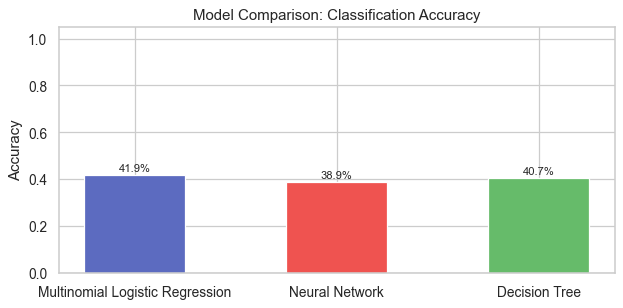

  Saved basic  → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/basic/logistic_regression.pkl
  Saved basic  → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/basic/neural_network.pkl
  Saved basic  → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/basic/decision_tree.pkl


In [61]:
print("\n── Basic Model Comparison ──")
evaluator.print_score_table(basic_models, "Basic", basic_reports)
visualizer.plot_model_comparison(
    list(basic_reports.keys()),
    [v["accuracy"] for v in basic_reports.values()],
)
config.SAVED_MODELS_BASIC_DIR.mkdir(parents=True, exist_ok=True)
for model in basic_models:
    path = config.SAVED_MODELS_BASIC_DIR / config.MODEL_FILE_MAP[model.get_name()]
    model.save_basic(path)
    print(f"  Saved basic  → {path}")

### **Best Training and Evaluation**


{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Train acc: 0.3679023932426091% 	 Val acc: 0.3380281690140845%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l1', 'random_state': 42}
Train acc: 0.3998122946973252% 	 Val acc: 0.4084507042253521%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'elasticnet', 'random_state': 42}
Train acc: 0.3669638667292351% 	 Val acc: 0.36619718309859156%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': None, 'random_state': 42}
Train acc: 0.3674331299859221% 	 Val acc: 0.3380281690140845%

{'eta0': 0.1, 'learning_rate': 'optimal', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Train acc: 0.3683716564992961% 	 Val acc: 0.31690140845070425%

{'eta0': 0.1, 'learning_rate': 'optimal', 'loss': 'log_loss', 'max_iter': 200, 'penalty': '

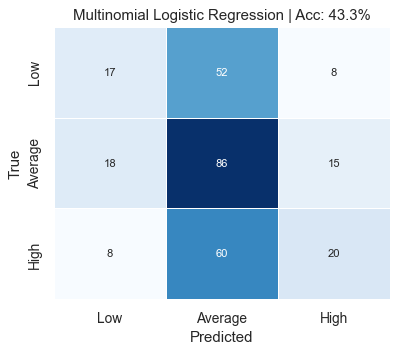

Best accuracy:  0.44014084507042256 %
Best grid:  {'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l1', 'random_state': 42}
Trained: Multinomial Logistic Regression
Best params: {'eta0': 0.01, 'learning_rate': 'adaptive', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l1', 'random_state': 42}
Model Fitting: {'training accuracy': 0.45424683247301734, 'validation accuracy': 0.44014084507042256}

── Multinomial Logistic Regression — Best Metrics ──

  Multinomial Logistic Regression  |  Accuracy: 39.6%
              precision    recall  f1-score   support

         Low       0.37      0.16      0.23       116
     Average       0.41      0.71      0.52       180
        High       0.34      0.18      0.23       131

    accuracy                           0.40       427
   macro avg       0.37      0.35      0.33       427
weighted avg       0.38      0.40      0.35       427



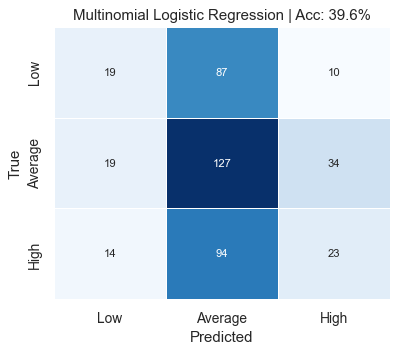

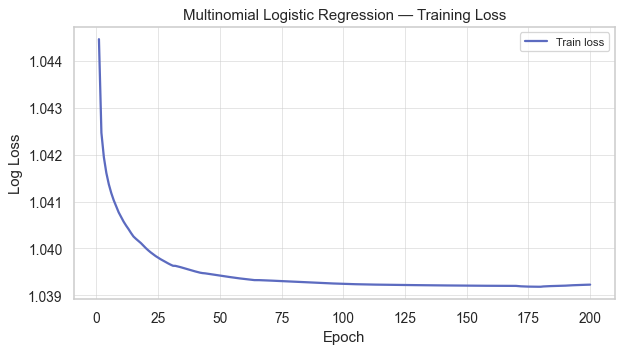


Training Neural Network (best) — running grid search ...

Grid Search: 72 combinations to evaluate
Parameters: ['hidden_layers', 'learning_rate', 'max_iterations', 'dropout_rate', 'weight_decay']

[1/72] Testing: {'hidden_layers': (128, 64, 32), 'learning_rate': 0.001, 'max_iterations': 100, 'dropout_rate': 0.3, 'weight_decay': 0.0001}
  Epoch 10/100  loss=1.0833  val_loss=1.0756
  Epoch 20/100  loss=1.0771  val_loss=1.0651
  Epoch 30/100  loss=1.0611  val_loss=1.0562
  Epoch 40/100  loss=1.0482  val_loss=1.0474
  Epoch 50/100  loss=1.0419  val_loss=1.0397
  Epoch 60/100  loss=1.0349  val_loss=1.0361
  Epoch 70/100  loss=1.0235  val_loss=1.0329
  Epoch 80/100  loss=1.0170  val_loss=1.0327
  Epoch 90/100  loss=1.0010  val_loss=1.0320
  Epoch 100/100  loss=0.9922  val_loss=1.0349
  Restored best model from epoch with val_loss=1.0318
  → Validation Accuracy: 0.4401

[2/72] Testing: {'hidden_layers': (128, 64, 32), 'learning_rate': 0.001, 'max_iterations': 100, 'dropout_rate': 0.3, 'weigh

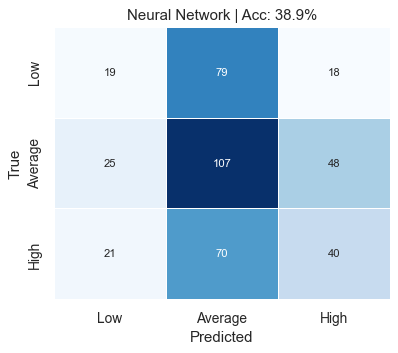

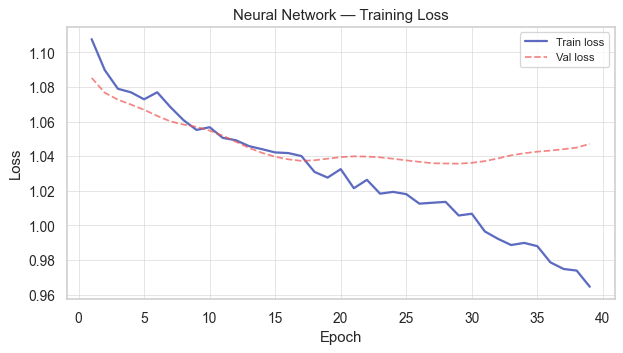


────────────────────────────────────────────────────
  Training: Decision Tree
────────────────────────────────────────────────────

  [Phase 1] Baseline overfitting check + depth sweep
      depth | train_acc |  val_acc |      gap
  ----------+-----------+----------+---------
   baseline |    0.8897 |   0.3768 |   0.5130  ← overfitting baseline
          5 |    0.5007 |   0.3908 |   0.1099
          7 |    0.5669 |   0.4225 |   0.1443
         10 |    0.7006 |   0.3908 |   0.3098
         13 |    0.7996 |   0.3768 |   0.4229
  unlimited |    0.8897 |   0.3768 |   0.5130

 Max training rounds (5) reached. Final train_acc = 0.8897

  [Phase 2] Validation check
  train_acc = 0.8897 | val_acc = 0.3768 | gap = 0.5130 (tolerance = 0.05)
  Gap too large. Starting manual grid search hypertuning ...

  [Phase 3] Manual grid search — 5760 combinations
  Best hyperparameters : {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 30, 'min_impurit

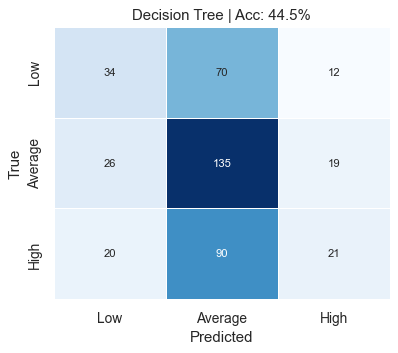

[Decision Tree] No loss curve available — Decision Trees are trained in a single pass with no iterative loss.


In [62]:
best_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    DecisionTreeModel(),
]

best_reports = {}
for model in best_models:
    model.train_best(X_train_t, ycat_train.values, X_val_t, ycat_val.values)

    # ── Per-model metrics ─────────────────────────────────────────────────────
    print(f"\n── {model.get_name()} — Best Metrics ──")
    preds = {model.get_name(): model.predict_best(X_test_t)}
    report = evaluator.classification_report_all(ycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    best_reports.update(report)



── Best Model Comparison ──

═══════════════════════════════════════════════════════════════════════════════════
  MODEL RESULTS SUMMARY — Best
═══════════════════════════════════════════════════════════════════════════════════
  Model                              Train Acc    Val Acc   Test Acc  Final Loss
  ──────────────────────────────────  ─────────  ─────────  ─────────  ──────────
  Multinomial Logistic Regression       45.42%     44.01%     39.58%      1.0392
  Neural Network                        51.15%     47.54%     38.88%      0.9646
  Decision Tree                         51.62%     44.37%     44.50%         n/a
═══════════════════════════════════════════════════════════════════════════════════



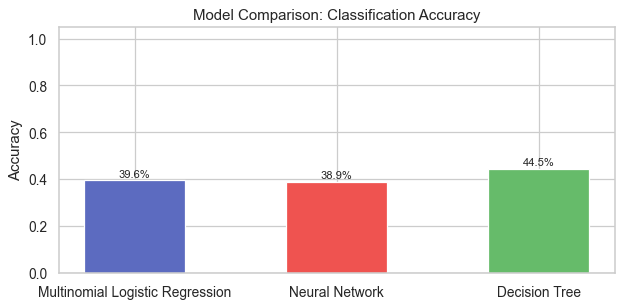

  Saved best   → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/best/logistic_regression.pkl
  Saved best   → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/best/neural_network.pkl
  Saved best   → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/best/decision_tree.pkl


In [63]:
print("\n── Best Model Comparison ──")
evaluator.print_score_table(best_models, "Best", best_reports)
visualizer.plot_model_comparison(
    list(best_reports.keys()),
    [v["accuracy"] for v in best_reports.values()],
)
config.SAVED_MODELS_BEST_DIR.mkdir(parents=True, exist_ok=True)
for model in best_models:
    path = config.SAVED_MODELS_BEST_DIR / config.MODEL_FILE_MAP[model.get_name()]
    model.save_best(path)
    print(f"  Saved best   → {path}")


# **Improving Model Performance**

- After examination of errors throughout the models, class imbalance was first tested due to model preference towards classifying data as "average stress level"
- Since there is no class imbalance found in the data, other forms of biases present within the data were examined. Avoidable bias found in the data set. Removal of outliers and removal of high-variance features that only acted as noise to models were implemented in order to have better visuals of data patterns.
- For multinomial logistic regression through SGD classifier, standardization of data was implemented since the method uses a gradient descent which is sensitive to oscillating values. Standardization would scale the data to be scaled to mean 0 and standard deviation of 1. It would balance the numbers in the data set so that the model can find the patterns of the data better.
- As a result, Validation Set performance increased across all models after data transformations were implemented. Varying changes to the test score can be attributed to the inherent state of the data being noisy and not having any features that could clearly distinguish between classes.

In [64]:
print("=" * 55)
print("  FEATURES USED")
print("=" * 55)

print(f"\nNumeric ({len(config.NUMERIC_COLS)}):")
for f in config.NUMERIC_COLS:
    print(f"  • {f}")

print(f"\nCategorical ({len(config.CATEGORICAL_COLS)}):")
for f in config.CATEGORICAL_COLS:
    print(f"  • {f}")

print(f"\nDerived ({len(config.DERIVED_COLS)}):")
for f in config.DERIVED_COLS:
    print(f"  • {f}")

print(f"\nTarget: {config.TARGET}  →  {config.TARGET_CATEGORY}  {config.CATEGORY_ORDER}")
print(f"\nTotal input features: {len(config.ALL_NUMERIC) + len(config.ALL_CATS)}")
print("=" * 55)

# ── Feature correlation with target (stress) ──────────────────────────────────
corr = (
    df_eda[config.ALL_NUMERIC + config.ALL_CATS + [config.TARGET]]
    .corr()[config.TARGET]
    .drop(config.TARGET)
    .sort_values(key=abs, ascending=False)
)

print("\n" + "=" * 48)
print("  FEATURE CORRELATION WITH TARGET (stress)")
print("=" * 48)
print(f"  {'Feature':<28} {'Corr':>7}")
print(f"  {'─'*28}  {'─'*7}")
for feat, val in corr.items():
    bar = "█" * int(abs(val) * 20)
    sign = "+" if val >= 0 else "-"
    print(f"  {feat:<28} {val:+.4f}  {sign}{bar}")
print("=" * 48)


  FEATURES USED

Numeric (14):
  • age
  • hours_work
  • social_media_use
  • rent
  • friends_count
  • highest_speed
  • dates
  • standard_drinks
  • countries
  • semesters
  • commute
  • data_interest
  • mark_goal
  • hours_studying

Categorical (8):
  • gender
  • relationship_status
  • drug_use_ans
  • student_type
  • mainstream_advanced
  • lecture_mode
  • study_type
  • learner_style

Derived (3):
  • financial_pressure
  • work_study_ratio
  • social_engagement

Target: stress  →  stress_category  ['Low', 'Average', 'High']

Total input features: 25

  FEATURE CORRELATION WITH TARGET (stress)
  Feature                         Corr
  ────────────────────────────  ───────
  hours_work                   +0.1067  +██
  age                          +0.1014  +██
  rent                         +0.0971  +█
  social_engagement            -0.0850  -█
  gender                       -0.0789  -█
  social_media_use             +0.0760  +█
  student_type                 +0.0690  +█
  

In [65]:

from scipy.stats import chisquare
counts = df_eda[config.TARGET].value_counts().values
stat, p = chisquare(counts)
print(f"χ² = {stat:.4f},  p = {p:.4f}")


χ² = 1004.1914,  p = 0.0000


### **Refined Model — Low-Correlation Features Removed**
Features with near-zero correlation to the target are dropped to reduce noise and improve generalisation.

**Removed features** (|corr| < 0.05):
`highest_speed`, `friends_count`, `dates`, `commute`, `standard_drinks`, `data_interest`, `countries`, `relationship_status`, `lecture_mode`, `drug_use_ans`, `study_type`, `learner_style`, `financial_pressure`

In [66]:

DROP_NUMERIC     = {"highest_speed", "friends_count", "dates", "commute",
                    "standard_drinks", "data_interest", "countries"}
DROP_CATEGORICAL = {"relationship_status", "lecture_mode", "drug_use_ans",
                    "study_type", "learner_style"}
DROP_DERIVED     = {"financial_pressure"}

R_NUMERIC_COLS = [f for f in config.NUMERIC_COLS     if f not in DROP_NUMERIC]
R_CAT_COLS     = [f for f in config.CATEGORICAL_COLS if f not in DROP_CATEGORICAL]
R_DERIVED_COLS = [f for f in config.DERIVED_COLS     if f not in DROP_DERIVED]
R_ALL_NUMERIC  = R_NUMERIC_COLS + R_DERIVED_COLS
R_ALL_CATS     = R_CAT_COLS

print(f"Numeric     : {len(config.NUMERIC_COLS)} → {len(R_NUMERIC_COLS)}   {R_NUMERIC_COLS}")
print(f"Categorical : {len(config.CATEGORICAL_COLS)} → {len(R_CAT_COLS)}   {R_CAT_COLS}")
print(f"Derived     : {len(config.DERIVED_COLS)} → {len(R_DERIVED_COLS)}   {R_DERIVED_COLS}")
print(f"\nTotal features: {len(config.ALL_NUMERIC)+len(config.ALL_CATS)} → {len(R_ALL_NUMERIC)+len(R_ALL_CATS)}")


Numeric     : 14 → 7   ['age', 'hours_work', 'social_media_use', 'rent', 'semesters', 'mark_goal', 'hours_studying']
Categorical : 8 → 3   ['gender', 'student_type', 'mainstream_advanced']
Derived     : 3 → 2   ['work_study_ratio', 'social_engagement']

Total features: 25 → 12


In [67]:
print("Shapes BEFORE outlier removal:")
print(f"  Train : {train_df.shape}")
print(f"  Val   : {validation_df.shape}")
print(f"  Test  : {test_df.shape}")

iqr_bounds = {}
for col in R_NUMERIC_COLS:
    q1 = train_df[col].quantile(0.25)
    q3 = train_df[col].quantile(0.75)
    iqr = q3 - q1
    iqr_bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

def apply_iqr_filter(df):
    mask = pd.Series(True, index=df.index)
    for col, (lo, hi) in iqr_bounds.items():
        mask &= df[col].between(lo, hi)
    return df[mask].reset_index(drop=True)

r_train_df = apply_iqr_filter(train_df)
r_val_df   = apply_iqr_filter(validation_df)
r_test_df  = apply_iqr_filter(test_df)

rycat_train = r_train_df[config.TARGET_CATEGORY]
rycat_val   = r_val_df[config.TARGET_CATEGORY]
rycat_test  = r_test_df[config.TARGET_CATEGORY]

print("\nShapes AFTER outlier removal:")
print(f"  Train : {r_train_df.shape}  (removed {len(train_df) - len(r_train_df)} rows)")
print(f"  Val   : {r_val_df.shape}  (removed {len(validation_df) - len(r_val_df)} rows)")
print(f"  Test  : {r_test_df.shape}  (removed {len(test_df) - len(r_test_df)} rows)")


Shapes BEFORE outlier removal:
  Train : (2131, 26)
  Val   : (284, 26)
  Test  : (427, 26)

Shapes AFTER outlier removal:
  Train : (1473, 26)  (removed 658 rows)
  Val   : (205, 26)  (removed 79 rows)
  Test  : (288, 26)  (removed 139 rows)


In [68]:
# SGDClassifier requires scaled inputs; DataFrames are left unmodified for all other models
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_lr_num = Pipeline([("imputer", SimpleImputer(strategy="median")),
                    ("scaler",  StandardScaler())])
_lr_cat = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
_lr_ct  = ColumnTransformer([("num", _lr_num, R_ALL_NUMERIC),
                              ("cat", _lr_cat, R_ALL_CATS)])

lr_rX_train_t = _lr_ct.fit_transform(r_train_df[R_ALL_NUMERIC + R_ALL_CATS])
lr_rX_val_t   = _lr_ct.transform(r_val_df[R_ALL_NUMERIC + R_ALL_CATS])
lr_rX_test_t  = _lr_ct.transform(r_test_df[R_ALL_NUMERIC + R_ALL_CATS])

print("✓ LR-only scaled pipeline built (DataFrames unchanged)")
print(f"  Shapes — Train: {lr_rX_train_t.shape} | Val: {lr_rX_val_t.shape} | Test: {lr_rX_test_t.shape}")

✓ LR-only scaled pipeline built (DataFrames unchanged)
  Shapes — Train: (1473, 17) | Val: (205, 17) | Test: (288, 17)


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_num_noscale = Pipeline([("imputer", SimpleImputer(strategy="median"))])
_cat_pipe    = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
_no_scale_ct = ColumnTransformer([("num", _num_noscale, R_ALL_NUMERIC),
                                   ("cat", _cat_pipe,   R_ALL_CATS)])

rX_train_t = _no_scale_ct.fit_transform(r_train_df[R_ALL_NUMERIC + R_ALL_CATS])
rX_val_t   = _no_scale_ct.transform(r_val_df[R_ALL_NUMERIC + R_ALL_CATS])
rX_test_t  = _no_scale_ct.transform(r_test_df[R_ALL_NUMERIC + R_ALL_CATS])

# Scaled pipeline for Neural Network — includes StandardScaler on numeric cols
r_pipeliner   = Pipeliner(R_ALL_NUMERIC, R_ALL_CATS)
nn_rX_train_t = r_pipeliner.fit_transform(r_train_df[R_ALL_NUMERIC + R_ALL_CATS])
nn_rX_val_t   = r_pipeliner.transform(r_val_df[R_ALL_NUMERIC + R_ALL_CATS])
nn_rX_test_t  = r_pipeliner.transform(r_test_df[R_ALL_NUMERIC + R_ALL_CATS])


#### Basic Models — Refined Features

Trained: Multinomial Logistic Regression
Train acc: 0.4277  Val acc: 0.4293

── Multinomial Logistic Regression — Refined Basic Metrics ──

  Multinomial Logistic Regression  |  Accuracy: 37.8%
              precision    recall  f1-score   support

         Low       0.53      0.26      0.35        92
     Average       0.39      0.53      0.45       114
        High       0.28      0.30      0.29        82

    accuracy                           0.38       288
   macro avg       0.40      0.36      0.36       288
weighted avg       0.40      0.38      0.37       288



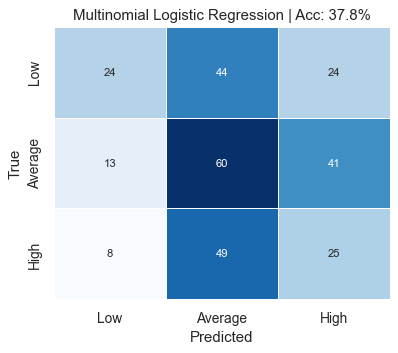

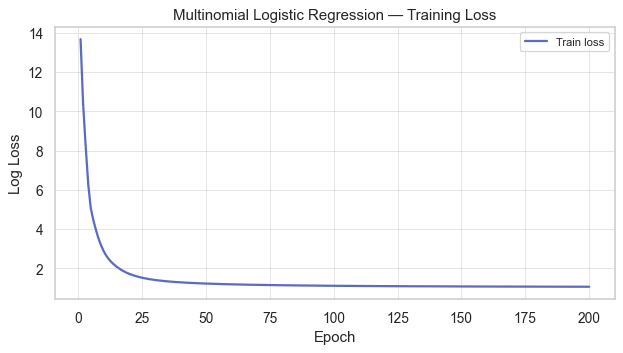


Training Neural Network (basic) ...
Early stopping at epoch 29
  Restored best model from epoch with val_loss=1.0679
  Train acc: 0.4229  Val acc: 0.4488

── Neural Network — Refined Basic Metrics ──

  Neural Network  |  Accuracy: 39.6%
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        92
     Average       0.40      1.00      0.57       114
        High       0.00      0.00      0.00        82

    accuracy                           0.40       288
   macro avg       0.13      0.33      0.19       288
weighted avg       0.16      0.40      0.22       288



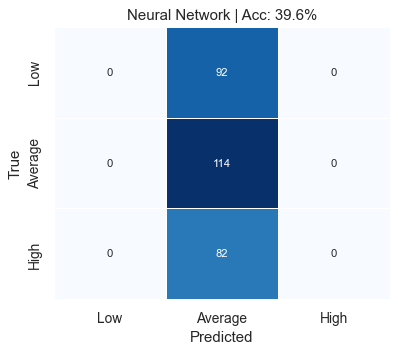

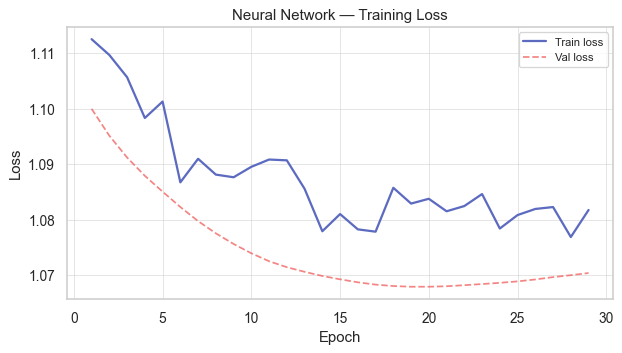

Trained (basic): Decision Tree
Train acc: 0.5193  Val acc: 0.3610

── Decision Tree — Refined Basic Metrics ──

  Decision Tree  |  Accuracy: 35.1%
              precision    recall  f1-score   support

         Low       0.33      0.14      0.20        92
     Average       0.37      0.54      0.44       114
        High       0.33      0.33      0.33        82

    accuracy                           0.35       288
   macro avg       0.34      0.34      0.32       288
weighted avg       0.34      0.35      0.33       288



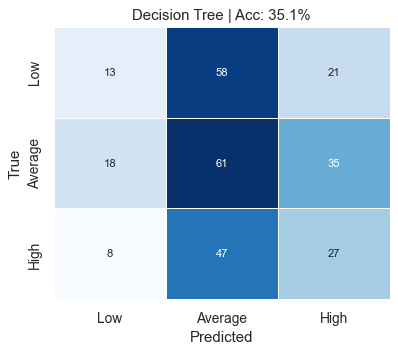

[Decision Tree] No loss curve available — Decision Trees are trained in a single pass with no iterative loss.

── Refined Basic Model Comparison ──

═══════════════════════════════════════════════════════════════════════════════════
  MODEL RESULTS SUMMARY — Refined Basic
═══════════════════════════════════════════════════════════════════════════════════
  Model                              Train Acc    Val Acc   Test Acc  Final Loss
  ──────────────────────────────────  ─────────  ─────────  ─────────  ──────────
  Multinomial Logistic Regression       42.77%     42.93%     37.85%      1.0670
  Neural Network                        42.29%     44.88%     39.58%      1.0817
  Decision Tree                         51.93%     36.10%     35.07%         n/a
═══════════════════════════════════════════════════════════════════════════════════



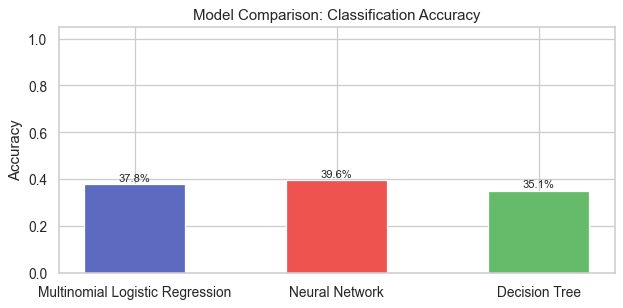

In [70]:
r_basic_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    DecisionTreeModel(),
]

r_basic_reports = {}
for model in r_basic_models:
    # Route each model to its appropriate scaled / unscaled input arrays
    if isinstance(model, LogisticRegressionModel):
        _X_tr, _X_val, _X_te = lr_rX_train_t, lr_rX_val_t, lr_rX_test_t
    elif isinstance(model, NeuralNetworkModel):
        _X_tr, _X_val, _X_te = nn_rX_train_t, nn_rX_val_t, nn_rX_test_t
    else:  # DecisionTree
        _X_tr, _X_val, _X_te = rX_train_t, rX_val_t, rX_test_t

    _X_tr  = np.nan_to_num(_X_tr,  nan=0.0)
    _X_val = np.nan_to_num(_X_val, nan=0.0)
    _X_te  = np.nan_to_num(_X_te,  nan=0.0)

    model.train_basic(_X_tr, rycat_train.values, _X_val, rycat_val.values)

    print(f"\n── {model.get_name()} — Refined Basic Metrics ──")
    preds = {model.get_name(): model.predict_basic(_X_te)}
    report = evaluator.classification_report_all(rycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    r_basic_reports.update(report)

print("\n── Refined Basic Model Comparison ──")
evaluator.print_score_table(r_basic_models, "Refined Basic", r_basic_reports)
visualizer.plot_model_comparison(
    list(r_basic_reports.keys()),
    [v["accuracy"] for v in r_basic_reports.values()],
)


#### Best Models — Refined Features

  REFINED BEST MODELS — Training
{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Train acc: 0.39035980991174474% 	 Val acc: 0.3902439024390244%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l1', 'random_state': 42}
Train acc: 0.38424983027834353% 	 Val acc: 0.35121951219512193%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'elasticnet', 'random_state': 42}
Train acc: 0.38832315003394435% 	 Val acc: 0.3951219512195122%

{'eta0': 0.1, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': None, 'random_state': 42}
Train acc: 0.39035980991174474% 	 Val acc: 0.3902439024390244%

{'eta0': 0.1, 'learning_rate': 'optimal', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Train acc: 0.4154786150712831% 	 Val acc: 0.36097560975609755%

{'eta0': 0.1, 'learning_rate': 'optimal', 'loss': 'log

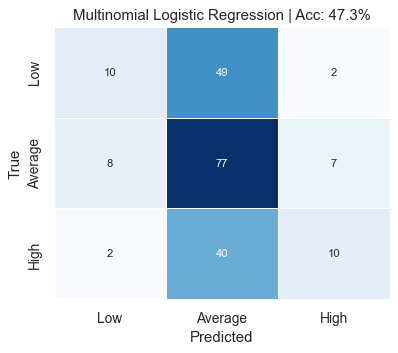

Best accuracy:  0.48292682926829267 %
Best grid:  {'eta0': 0.001, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Trained: Multinomial Logistic Regression
Best params: {'eta0': 0.001, 'learning_rate': 'constant', 'loss': 'log_loss', 'max_iter': 200, 'penalty': 'l2', 'random_state': 42}
Model Fitting: {'training accuracy': 0.43584521384928715, 'validation accuracy': 0.48292682926829267}

── Multinomial Logistic Regression — Refined Best Metrics ──

  Multinomial Logistic Regression  |  Accuracy: 39.6%
              precision    recall  f1-score   support

         Low       0.44      0.17      0.25        92
     Average       0.39      0.78      0.52       114
        High       0.36      0.11      0.17        82

    accuracy                           0.40       288
   macro avg       0.40      0.35      0.31       288
weighted avg       0.40      0.40      0.33       288



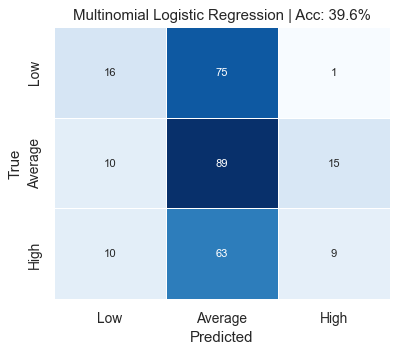

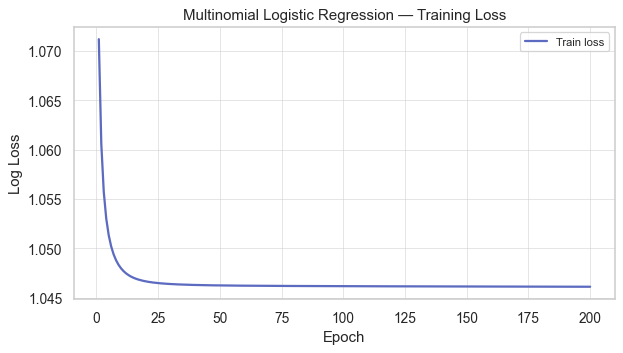


Training Neural Network (best) — running grid search ...

Grid Search: 72 combinations to evaluate
Parameters: ['hidden_layers', 'learning_rate', 'max_iterations', 'dropout_rate', 'weight_decay']

[1/72] Testing: {'hidden_layers': (128, 64, 32), 'learning_rate': 0.001, 'max_iterations': 100, 'dropout_rate': 0.3, 'weight_decay': 0.0001}
  Epoch 10/100  loss=1.0750  val_loss=1.0658
  Epoch 20/100  loss=1.0739  val_loss=1.0624
Early stopping at epoch 27
  Restored best model from epoch with val_loss=1.0621
  → Validation Accuracy: 0.4488

[2/72] Testing: {'hidden_layers': (128, 64, 32), 'learning_rate': 0.001, 'max_iterations': 100, 'dropout_rate': 0.3, 'weight_decay': 0.001}
  Epoch 10/100  loss=1.0754  val_loss=1.0662
  Epoch 20/100  loss=1.0744  val_loss=1.0626
Early stopping at epoch 27
  Restored best model from epoch with val_loss=1.0623
  → Validation Accuracy: 0.4488

[3/72] Testing: {'hidden_layers': (128, 64, 32), 'learning_rate': 0.001, 'max_iterations': 100, 'dropout_rate': 0

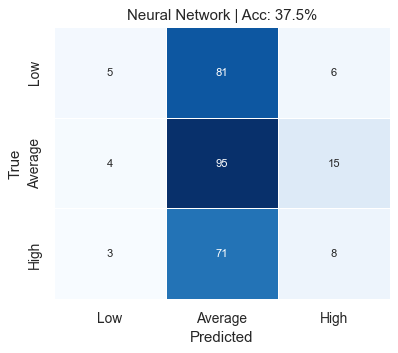

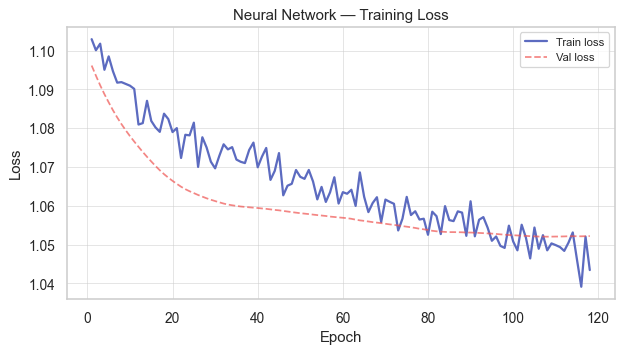


────────────────────────────────────────────────────
  Training: Decision Tree
────────────────────────────────────────────────────

  [Phase 1] Baseline overfitting check + depth sweep
      depth | train_acc |  val_acc |      gap
  ----------+-----------+----------+---------
   baseline |    0.8506 |   0.4000 |   0.4506  ← overfitting baseline
          5 |    0.5193 |   0.3610 |   0.1584
          7 |    0.5777 |   0.3707 |   0.2070
         10 |    0.7088 |   0.3561 |   0.3527
         13 |    0.7862 |   0.4098 |   0.3764
  unlimited |    0.8506 |   0.4000 |   0.4506

 Max training rounds (5) reached. Final train_acc = 0.8506

  [Phase 2] Validation check
  train_acc = 0.8506 | val_acc = 0.4000 | gap = 0.4506 (tolerance = 0.05)
  Gap too large. Starting manual grid search hypertuning ...

  [Phase 3] Manual grid search — 5760 combinations
  Best hyperparameters : {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 10, 'min_impurit

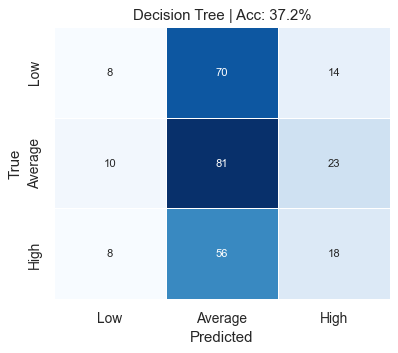

[Decision Tree] No loss curve available — Decision Trees are trained in a single pass with no iterative loss.

── Refined Best Model Comparison ──

═══════════════════════════════════════════════════════════════════════════════════
  MODEL RESULTS SUMMARY — Refined Best
═══════════════════════════════════════════════════════════════════════════════════
  Model                              Train Acc    Val Acc   Test Acc  Final Loss
  ──────────────────────────────────  ─────────  ─────────  ─────────  ──────────
  Multinomial Logistic Regression       43.58%     48.29%     39.58%      1.0461
  Neural Network                        44.47%     47.32%     37.50%      1.0434
  Decision Tree                         46.91%     45.37%     37.15%         n/a
═══════════════════════════════════════════════════════════════════════════════════



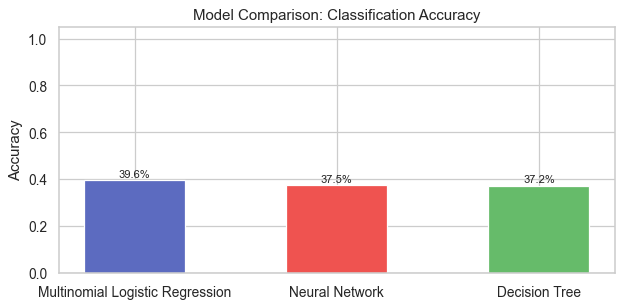

In [71]:

# ── Train best (refined) ──────────────────────────────────────────────────────
print("=" * 60)
print("  REFINED BEST MODELS — Training")
print("=" * 60)

r_best_models = [
    LogisticRegressionModel(),
    NeuralNetworkModel(),
    DecisionTreeModel(),
]

r_best_reports = {}
for model in r_best_models:
    # Route each model to its appropriate scaled / unscaled input arrays
    if isinstance(model, LogisticRegressionModel):
        _X_tr, _X_val, _X_te = lr_rX_train_t, lr_rX_val_t, lr_rX_test_t
    elif isinstance(model, NeuralNetworkModel):
        _X_tr, _X_val, _X_te = nn_rX_train_t, nn_rX_val_t, nn_rX_test_t
    else:
        _X_tr, _X_val, _X_te = rX_train_t, rX_val_t, rX_test_t

    # Sanitise inputs — replace any residual NaN with 0 before training
    _X_tr  = np.nan_to_num(_X_tr,  nan=0.0)
    _X_val = np.nan_to_num(_X_val, nan=0.0)
    _X_te  = np.nan_to_num(_X_te,  nan=0.0)

    model.train_best(_X_tr, rycat_train.values, _X_val, rycat_val.values)

    print(f"\n── {model.get_name()} — Refined Best Metrics ──")
    preds = {model.get_name(): model.predict_best(_X_te)}
    report = evaluator.classification_report_all(rycat_test.values, preds, config.CATEGORY_ORDER)
    evaluator.print_classification_reports(report)
    visualizer.plot_confusion_matrices(report, config.CATEGORY_ORDER)
    model.plot_loss_curve()
    r_best_reports.update(report)

print("\n── Refined Best Model Comparison ──")
evaluator.print_score_table(r_best_models, "Refined Best", r_best_reports)
visualizer.plot_model_comparison(
    list(r_best_reports.keys()),
    [v["accuracy"] for v in r_best_reports.values()],
)


In [72]:
config.SAVED_MODELS_REFINED_BEST_DIR.mkdir(parents=True, exist_ok=True)
for model in r_best_models:
    path = config.SAVED_MODELS_REFINED_BEST_DIR / config.MODEL_FILE_MAP[model.get_name()]
    model.save_best(path)
    print(f"  Saved refined best → {path}")


  Saved refined best → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/refined_best/logistic_regression.pkl
  Saved refined best → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/refined_best/neural_network.pkl
  Saved refined best → /Users/shawnemersonmac/Desktop/untitled folder/backend/data/refined_best/decision_tree.pkl


In [73]:

# ── Helper — extract best params from any model type ─────────────────────────
def get_best_params(model):
    if isinstance(model, LogisticRegressionModel):
        p = getattr(model, "best_grid", None)
        return p if p else "default (basic)"
    if isinstance(model, NeuralNetworkModel):
        return {
            "hidden_layers":  model.hidden_layers,
            "learning_rate":  model.learning_rate,
            "dropout_rate":   model.dropout_rate,
            "weight_decay":   model.weight_decay,
            "max_iterations": model.max_iterations,
        }
    if isinstance(model, DecisionTreeModel):
        if model._best_model is not None:
            sk = model._best_model.get_params()
            keys = list(model.HYPERPARAMETERS.keys())
            return {k: sk[k] for k in keys if k in sk}
        return "default (basic)"
    return "N/A"

def print_params_block(run_label, run_models):
    print(f"\n  ── {run_label} — Best Params ──")
    for m in run_models:
        p = get_best_params(m)
        print(f"    {m.get_name()}")
        if isinstance(p, dict):
            for k, v in p.items():
                print(f"      {k:<30} {v}")
        else:
            print(f"      {p}")

# ── Consolidated comparison — all four training runs ──────────────────────────
print("=" * 70)
print("  FULL MODEL COMPARISON — Before vs After Feature Refinement")
print("=" * 70)

all_runs = [
    ("Basic",         basic_models,    basic_reports),
    ("Best",          best_models,     best_reports),
    ("Refined Basic", r_basic_models,  r_basic_reports),
    ("Refined Best",  r_best_models,   r_best_reports),
]

for run_label, run_models, run_reports in all_runs:
    print(f"\n{'─' * 70}")
    print(f"  {run_label}")
    print(f"{'─' * 70}")
    evaluator.print_score_table(run_models, run_label, run_reports)
    print_params_block(run_label, run_models)

# ── Accuracy summary ──────────────────────────────────────────────────────────
print(f"\n{'=' * 70}")
print("  ACCURACY SUMMARY")
print(f"{'=' * 70}")
print(f"  {'Model':<30} {'Basic':>8} {'Best':>8} {'Ref Basic':>10} {'Ref Best':>10}")
print(f"  {'─'*30}  {'─'*8}  {'─'*8}  {'─'*10}  {'─'*10}")

model_names = list(basic_reports.keys())
for name in model_names:
    b  = basic_reports.get(name,        {}).get("accuracy", float("nan"))
    be = best_reports.get(name,         {}).get("accuracy", float("nan"))
    rb = r_basic_reports.get(name,      {}).get("accuracy", float("nan"))
    rv = r_best_reports.get(name,       {}).get("accuracy", float("nan"))
    delta = rv - b if not (rv != rv or b != b) else float("nan")
    arrow = ("▲" if delta > 0 else "▼" if delta < 0 else "►") + f" {abs(delta):.4f}"
    print(f"  {name:<30} {b:>8.4f}  {be:>8.4f}  {rb:>10.4f}  {rv:>10.4f}   {arrow}")
print(f"{'=' * 70}")


  FULL MODEL COMPARISON — Before vs After Feature Refinement

──────────────────────────────────────────────────────────────────────
  Basic
──────────────────────────────────────────────────────────────────────

═══════════════════════════════════════════════════════════════════════════════════
  MODEL RESULTS SUMMARY — Basic
═══════════════════════════════════════════════════════════════════════════════════
  Model                              Train Acc    Val Acc   Test Acc  Final Loss
  ──────────────────────────────────  ─────────  ─────────  ─────────  ──────────
  Multinomial Logistic Regression       43.50%     38.38%     41.92%      1.0634
  Neural Network                        50.12%     45.07%     38.88%      1.0182
  Decision Tree                         50.07%     39.08%     40.75%         n/a
═══════════════════════════════════════════════════════════════════════════════════


  ── Basic — Best Params ──
    Multinomial Logistic Regression
      default (basic)
    Neura

### **Model Performance Accuracy and Hyperparameters**

## Basic

| Model | Train Acc | Val Acc | Test Acc | Final Loss |
|---|---|---|---|---|
| Multinomial Logistic Regression | 43.50% | 38.38% | 41.92% | 1.0634 |
| Neural Network | 50.12% | 45.07% | 38.88% | 1.0182 |
| Decision Tree | 50.07% | 39.08% | 40.75% | n/a |

**Best Params — Basic**
- **Multinomial Logistic Regression:** default (basic)
- **Neural Network:** hidden_layers: (128, 64, 32) · learning_rate: 0.001 · dropout_rate: 0.5 · weight_decay: 0.0001 · max_iterations: 500
- **Decision Tree:** default (basic)

---

## Best

| Model | Train Acc | Val Acc | Test Acc | Final Loss |
|---|---|---|---|---|
| Multinomial Logistic Regression | 45.42% | 44.01% | 39.58% | 1.0392 |
| Neural Network | 51.15% | 47.54% | 38.88% | 0.9646 |
| Decision Tree | 51.62% | 44.37% | 44.50% | n/a |

**Best Params — Best**
- **Multinomial Logistic Regression:** eta0: 0.01 · learning_rate: adaptive · loss: log_loss · max_iter: 200 · penalty: l1 · random_state: 42
- **Neural Network:** hidden_layers: (128, 64, 32) · learning_rate: 0.005 · dropout_rate: 0.3 · weight_decay: 0.0001 · max_iterations: 100
- **Decision Tree:** criterion: gini · max_depth: 7 · min_samples_split: 2 · min_samples_leaf: 1 · max_leaf_nodes: 30 · min_impurity_decrease: 0.0

---

## Refined Basic

| Model | Train Acc | Val Acc | Test Acc | Final Loss |
|---|---|---|---|---|
| Multinomial Logistic Regression | 42.77% | 42.93% | 37.85% | 1.0670 |
| Neural Network | 42.29% | 44.88% | 39.58% | 1.0817 |
| Decision Tree | 51.93% | 36.10% | 35.07% | n/a |

**Best Params — Refined Basic**
- **Multinomial Logistic Regression:** default (basic)
- **Neural Network:** hidden_layers: (128, 64, 32) · learning_rate: 0.001 · dropout_rate: 0.5 · weight_decay: 0.0001 · max_iterations: 500
- **Decision Tree:** default (basic)

---

## Refined Best

| Model | Train Acc | Val Acc | Test Acc | Final Loss |
|---|---|---|---|---|
| Multinomial Logistic Regression | 43.58% | 48.29% | 39.58% | 1.0461 |
| Neural Network | 44.47% | 47.32% | 37.50% | 1.0434 |
| Decision Tree | 46.91% | 45.37% | 37.15% | n/a |

**Best Params — Refined Best**
- **Multinomial Logistic Regression:** eta0: 0.001 · learning_rate: constant · loss: log_loss · max_iter: 200 · penalty: l2 · random_state: 42
- **Neural Network:** hidden_layers: (64, 32) · learning_rate: 0.001 · dropout_rate: 0.5 · weight_decay: 0.0001 · max_iterations: 300
- **Decision Tree:** criterion: gini · max_depth: 4 · min_samples_split: 2 · min_samples_leaf: 1 · max_leaf_nodes: 10 · min_impurity_decrease: 0.0

---

## Accuracy Summary

| Model | Basic | Best | Refined Basic | Refined Best | Change |
|---|---|---|---|---|---|
| Multinomial Logistic Regression | 0.4192 | 0.3958 | 0.3785 | 0.3958 | ▼ 0.0234 |
| Neural Network | 0.3888 | 0.3888 | 0.3958 | 0.3750 | ▼ 0.0138 |
| Decision Tree | 0.4075 | 0.4450 | 0.3507 | 0.3715 | ▼ 0.0360 |

## Model Discussion

### Multinomial Logistic Regression
Multinomial Logistic Regression performed weakest overall, peaking at 41.92% test accuracy in
its Basic configuration. Tuning and feature refinement consistently hurt test performance,
exposing the model's inability to capture non-linear boundaries between stress classes. The wide
validation–test gap in Refined Best (48.29% vs 39.58%) further confirms overfitting to
validation-specific patterns. Logistic regression's linear assumption is simply too restrictive
for this dataset.

---

### Neural Network
Despite being the most complex model, the Neural Network plateaued at 38.88%–39.58% test
accuracy across all configurations. Regularization through dropout and weight decay failed to
meaningfully improve generalization, suggesting the dataset is too noisy and small for deep
representations to form. The model has the capacity to learn but lacks reliable signal to
latch onto, making added complexity a liability rather than an advantage.

---

### Decision Tree
The Decision Tree achieved the highest test accuracy at 44.50% in its Best configuration,
indicating the data has some threshold-based structure that trees can exploit. It was, however,
the most sensitive to feature changes — dropping to 35.07% in Refined Basic when key splitting
features were altered. A moderately deep tree (max_depth=7, max_leaf_nodes=30) with the
original feature set proved to be the most effective combination overall.

---

### Best Model: Decision Tree (~44%)
The ~44% accuracy ceiling across all models reflects a fundamental data limitation — the
collected features do not cleanly separate stress levels due to the inherently subjective and
overlapping nature of stress. Consistent training–test gaps across all configurations confirm
that learned patterns struggle to generalize to unseen data. Meaningful improvements would
likely require more discriminative features, larger sample sizes, or a reformulated target
variable to reduce class overlap.

## References

Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth & Brooks.
Used to implement the CART (Classification and Regression Trees) algorithm: the Gini impurity splitting criterion and recursive binary tree construction in _DTCore.

Decision Trees. (n.d.). Scikit-learn. https://scikit-learn.org/stable/modules/tree.html
Referenced for understanding sklearn's DecisionTreeClassifier API and cross-validating our from-scratch implementation against documented behaviour.

Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning, 1*(1), 81–106. https://doi.org/10.1007/BF00116251
Early decision tree paper (ID3). Referenced to contrast information gain (ID3) with Gini impurity (CART), justifying our choice of Gini for multi-class classification.

SGDClassifier. (n.d.). Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html

## AI Statement

All group members declare the following regarding the use of AI tools in this project:

**Tools used:** Claude (Anthropic, claude.ai)

**Purpose:** Conceptual clarification only, specifically on idealizing the data split ideal for the given dataset with the target prediction of stress levels.

---

### Prompts and Responses

---

**Prompt:**
> Is a data split of train = 75%, val = 15%, and test = 10% the best dataset to be used? considering these distributions

**Response:**

The 75/15/10 split is actually not ideal for this dataset. Here's why:

The majority class baseline is already ~42% (Average class dominates), and the dataset has 2,842 usable samples. With a 10% test set you only get ~285 test samples — meaning the minority Low class gets roughly 79 samples in test. That's too few for reliable F1 estimates, especially for a class the tree already struggles with. The standard error on the Low class proportion balloons to ±2.64% vs ±2.16% with a balanced 70/15/15 split.

**Why 75/15/10 hurts this dataset specifically:**

The Low class (27.2%) is already the tree's weakest point — it scored F1 = 0.00 on the test set. Shrinking the test set to 10% gives you only 79 Low-class samples, which means a single run-of-bad-luck classification shift of a few samples can swing the Low-class F1 by several percentage points. Your evaluation becomes unreliable for the exact class you most need to measure.

The extra 5% of training samples (1,989 → 2,131) gained from 75/15/10 also does virtually nothing here — the problem isn't data starvation, it's that survey self-report data has inherent noise that no amount of extra training rows can fix.

---

**Prompt:**
> Is there a way for us to increase or at the very least improve training and validation for the low and high class considering that there is a small sample size for that compared to average class?

**Response:**

Yes, absolutely. The core technique for this is **SMOTE (Synthetic Minority Oversampling Technique)** applied only to the training set.

The class imbalance in your dataset is actually mild — the ratio is only about 1.55:1 (Average:Low). SMOTE is most critical at 5:1 or higher. But given that your Low class is scoring F1 = 0.00 and your rubric rewards improvement strategies, using SMOTE is still worth doing because it directly targets what Section 8 asks you to justify.